# Seifenhaut: Minimierung der Wirkung

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import scienceplots
plt.style.use("science")

In [35]:
R = 1
D = 1
D_crit = 1.3257

alpha = R*2 / D

x = np.linspace(-D/2, D/2, 1000)

In [36]:
def f(xi):
    return np.cosh(xi) - alpha * xi

def bisect(f, a, b, tol=1e-10, max_iter=200):
    fa = f(a)
    fb = f(b)
    if fa * fb > 0:
        return None  # Kein Vorzeichenwechsel -> keine Lösung hier
    for _ in range(max_iter):
        m = 0.5 * (a + b)
        fm = f(m)
        if abs(fm) < tol:
            return m
        if fa * fm <= 0:
            b, fb = m, fm
        else:
            a, fa = m, fm
    return 0.5 * (a + b)

In [37]:
y = lambda x, k : k*np.cosh(x/k)

xis = np.linspace(1e-6, 20, 5000)
roots = []

for i in range(len(xis) - 1):
    a, b = xis[i], xis[i+1]
    if f(a) * f(b) < 0:
        root = bisect(f, a, b)
        if root is not None:
            roots.append(root)

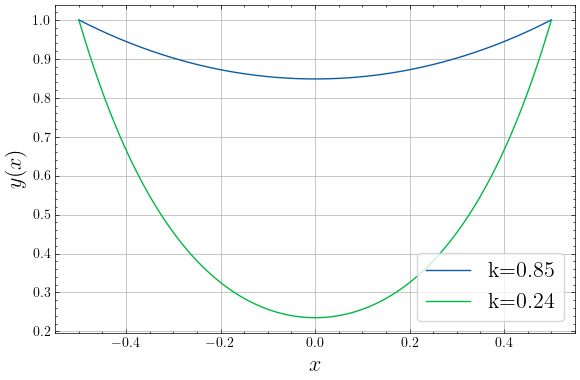

In [38]:
fig, ax = plt.subplots(1,1, figsize=(6, 4))
for xi in roots:
    k = D / (2 * xi)
    ax.plot(x, y(x, k), label=f'k={k:.2f}')

ax.set_ylabel(r'$y(x)$', fontsize=16)
ax.set_xlabel(r'$x$', fontsize=16)
ax.grid(True)
ax.legend(loc='lower right', frameon=True, fontsize=16)
plt.tight_layout()

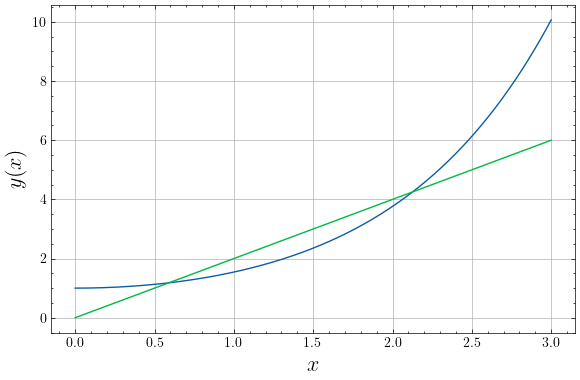

In [41]:
fig, ax = plt.subplots(1,1, figsize=(6, 4))
x_p = np.linspace(0, 3, 1000)
ax.plot(x_p, np.cosh(x_p))
ax.plot(x_p, alpha*x_p)

ax.set_ylabel(r'$y(x)$', fontsize=16)
ax.set_xlabel(r'$x$', fontsize=16)
ax.grid(True)
plt.tight_layout()